# Flight mechanincs 2 : Phase 3
##### ✅Groupe name = ✈️ <br>
##### ✅Groupe members = <b> Seyed Mani Seyed SalehiZadeh, Sarah Barati, Arshia Alizadeh </b>
 ---

## Problem 3.
Inorder for the Bravo I airplane to have a response the provided system the eigenvalues of L and A must be equal to one another. <br/>
The Full State FeedBack Control can be used for this perpouse.


Steps 
<ul>
<li>Step 1: Form the A matrix of the BRAVO I </li>
<li>Step 2: Find the eigenvalues of L </li>
<li>Step 3: Use the sp.signal.place_poles() to perform the pole placement </li>
<li>step 4: Check the eigenvalues of the resulting system </li>
</ul>

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import control

In [6]:
# Entering the Bravo I data in flight condition #1
X_u = -0.017
X_alpha = 0.026
Z_u = -0.143
Z_alpha = -1.02
Z_q = -0.0076
Z_elevator = -0.064
M_u = 0
M_alpha = 1.4
M_alpha_dot = -0.66
M_q = -0.53
M_elevator = -11.56
X_elevator = 0      # Data not provided in the Automatic Fligth Control Systems-Donald Mclean


# Flight condition information
U0 = 136    # [m/s]
g = 9.81    # [m/s^2]

# The stability dderivative coefficients containing the w
X_w = X_alpha * 1/ U0
M_w = M_alpha * 1/ U0
Z_w = Z_alpha * 1/U0
M_w_dot = M_alpha_dot * 1//U0

# The A matrix of the BRAVO I
A = np.array([
    [X_u, X_w, 0, -g],
    [Z_u, Z_w, U0, 0],
    [M_u + M_w_dot * Z_u, M_w + M_w_dot * Z_w, M_q + M_w_dot * U0, 0],
    [0,0,1,0]
])

# The B matrix of the BRAVO I
B = np.array([
    [X_elevator],
    [Z_elevator],
    [M_elevator + M_w_dot * Z_elevator ],
    [0]
])

# The L matrix (Desiered performance)
L = np.array([
    [-0.02, -0.02, 0, -9.81],
    [-0.002, -1.85, 1, 0],
    [0, -1.86, -1.4, 0],
    [0, 0, 1, 0]
])

Finding the desired pole locations and performing the poleplacement

In [7]:
# Finding the desiered Eigenvalues 
DesiredEigenValues = np.linalg.eigvals(L)

# Performing the pole placement using the Scipy
FSFB = sp.signal.place_poles(A, B,DesiredEigenValues, method="YT")
K = FSFB.gain_matrix


Checking the pole placement results

In [9]:
np.linalg.eigvals(A - B@K)

array([-1.62801663+1.34568412j, -1.62801663-1.34568412j,
       -0.00698337+0.09017302j, -0.00698337-0.09017302j])

In [ ]:
DesiredEigenValues

array([-1.62801663+1.34568412j, -1.62801663-1.34568412j,
       -0.00698337+0.09017302j, -0.00698337-0.09017302j])

----

## Problem 4.

<b> a) Show that for such an aircraft there must be always two unstable roots. </b>

Let's first assess the charactrestic equation of this plant $|A-\lambda I|$ (is also the same as the denumerator of the transfer functions)
$$
\Delta_{lat}(s) = s^4 + d_{1} s^3 + d_{2} s^2 + d_{3} s + d_{4} 
$$

let's first make several important points
1) If a plane is statically unstable then the plane is definatily dyanmically unstable 
2) If a plane is dynamically unstable it will have atleast one root on the right half side of the plane

Now since the $N'_{\beta} < 0$ the plane is statically unstable and consequently it is also dynamically unstable. So there exist at least one root for the charactrestic equation on the right side.
On the other hand since 
$$
\lim{x \to \infty}{\Delta_{lat}(s)} = +\infty
$$

But since at $S = 0$ the 
$$
\Delta_{lat}(0) = d_{4} = \frac{g}{U_{0}}(N'_{r} L'_{\beta} - L'_{r} N'_{\beta})
$$

This value is a postive number since the $\frac{g}{U_{0}} > 0 $ and assuming the other coefficients of stability derivatives are stable the $ L'_{r} > 0 $ and the 
$N'_{r} < 0 $ and $L'_{\beta} < 0 $ thus the $d_{4} > 0$. And there is atleast one root one the right side. which means the valus of the charactrestic equation will initally be decreasing until it becomes zero and then negative, but since the function has to go to positve inifity after some time its value will start to increase again thus becomming zero atleast one more time. 

In [33]:
# Entering the information of the aircraft
Yv = -0.2
Y_rudder = 0
N_prime_beta = -2.03
N_prime_r = -0.2
L_prime_beta = -5
N_prime_p = -0.07
N_prime_aileron = 0.3
L_prime_p = -2.5
L_prime_aileron = 20
N_prime_rudder = -3
L_prime_r = 3
L_prime_rudder = 1.4

U0 = 0.4 * (1.4*288*288)**0.5

# Finding the stability derivative coeffcients with v
L_prime_v = L_prime_beta * 1/U0
N_prime_v = N_prime_aileron * 1/U0

# We have assumed the gama0 is small

# Forming the latteral A and B matrix
A_lat = np.array([
    [Yv, 0, U0, -9.81, 0],
    [L_prime_v, L_prime_p, L_prime_r, 0, 0],
    [N_prime_v, N_prime_p, N_prime_p, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0]
])

B_lat = np.array([
    [0, 0],
    [L_prime_aileron, L_prime_rudder],
    [N_prime_aileron, N_prime_rudder],
    [0,0],
    [0,0]
])

Finding the eigenvalues of the $A_{latitde}$

In [ ]:
np.linalg.eigvals(A_lat)

array([ 0.        , -2.21349913, -1.13034093,  0.54480058,  0.02903948])

As predicted the A contains 2 unstable poles

<b> Part C) Let's setup the transfer function of the $\frac{r(s)}{\delta_{r}(s)}$ and then design a controller to stabilize it </b>

Text(0.5, 1.0, 'The controlled resposne vs uncontrolled resposne ')

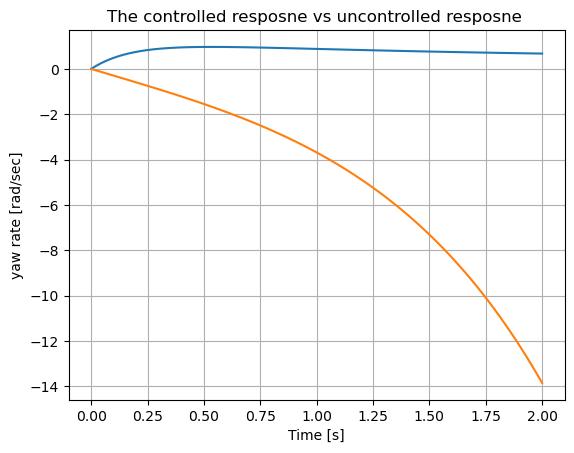

In [ ]:
num = [N_prime_rudder, -Yv * N_prime_rudder + Y_rudder/U0]
dnum = [1, -(Yv + N_prime_r), (N_prime_beta + Yv * N_prime_r)]

plant = control.tf(num, dnum)

# After using the PID tunner in matlab the constant gain of Kp = 2.174 is selected
# The plant will become
num = [6.5, 1.3]
dnum = [1, 6.12, 3.2]

controlled_sys = control.tf(num, dnum)

time = np.linspace(0,2, 100)

_, trajectory_uncontrolled = control.step_response(plant, time)
_, trajectory_controlled= control.step_response(controlled_sys, time)

# Plotting the response 
plt.plot(time, trajectory_controlled)
plt.plot(time, trajectory_uncontrolled)
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("yaw rate [rad/sec]")
plt.title("The controlled resposne vs uncontrolled resposne to step input ")

<b> Part c) Will the feedback control scheme devised in part (c) stabilize all the aircraft's modes? </B>

>No. It will not. since the control scheme was derived base on the transfer function of the 2DOF approxiamtion. And since the 2DOF approximation contains only a single non stable mode, the other unstable mode was unobsevrable during the design of the above control scheme. Thus in general the second unstable modes is still present in the system

** Note: Since the other unstable model is also effected by the rudder a controller may be found that accidentaly stabilizes the second mode at the same time. But statistically it is extremely unlikely since we are essentially blindfold when it comes down to designing the controller for the second mode.**

** Note: This is a classical example of how pole zero cancellations and approximation done in the S-domain can cause controllability and observability problems **

<b>Part d) Using any suitable method determine a feedback control law which will result in the controlled aircraft being stable.</b>

We will use LQR 

In [68]:
# Selecting the Q matrix
Q = 2* np.eye(5)

# Selecting the R matrix
R = np.eye(2)

# Finding the optimal kalman gain
k, _, _ = control.lqr(A_lat, B_lat, Q, R)
k = np.array(K)

# Finding the eigenvalues of the closed loop system
np.linalg.eigvals(A-B@K)


array([-1.62801663+1.34568412j, -1.62801663-1.34568412j,
       -0.00698337+0.09017302j, -0.00698337-0.09017302j])

All four eigenvalus have negative real componenet-> The plant is now stable